In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from datasets import load_dataset, Image as HFImage, DatasetDict
import json
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = load_dataset("Codatta/MM-Food-100K")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

MM-Food-100K.csv:   0%|          | 0.00/28.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_url', 'camera_or_phone_prob', 'food_prob', 'dish_name', 'food_type', 'ingredients', 'portion_size', 'nutritional_profile', 'cooking_method', 'sub_dt'],
        num_rows: 100000
    })
})


In [ ]:
print(f'Number of features: {len(dataset['train'].features)}')

Number of features: 10


In [ ]:
train_test_split = dataset['train'].train_test_split(test_size=0.1, seed=42)
train_val_split = train_test_split['train'].train_test_split(test_size=0.11, seed=42)

# merge back into a single DatasetDict
dataset = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'],
    'test': train_test_split['test']
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image_url', 'camera_or_phone_prob', 'food_prob', 'dish_name', 'food_type', 'ingredients', 'portion_size', 'nutritional_profile', 'cooking_method', 'sub_dt'],
        num_rows: 80100
    })
    validation: Dataset({
        features: ['image_url', 'camera_or_phone_prob', 'food_prob', 'dish_name', 'food_type', 'ingredients', 'portion_size', 'nutritional_profile', 'cooking_method', 'sub_dt'],
        num_rows: 9900
    })
    test: Dataset({
        features: ['image_url', 'camera_or_phone_prob', 'food_prob', 'dish_name', 'food_type', 'ingredients', 'portion_size', 'nutritional_profile', 'cooking_method', 'sub_dt'],
        num_rows: 10000
    })
})


#BUILD NETWORK


In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Modified output to 4 for protein/carb/fat/calories
class NutritionPredictor(nn.Module):
    def __init__(self, input_dim=2048, output_dim=4):
        super(NutritionPredictor, self).__init__()
        self.name = 'nutrition_predictor_dropout_256'
        self.regressor = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.regressor(x)

model = NutritionPredictor().to(device)

Using device: cuda


In [ ]:
# Path to the existing saved model file
model_file_path = "/content/model_nutrition_predictor_dropout_256_bs32_lr0.001_epoch49"

# Directory to store future checkpoints
checkpoint_dir = "/content/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# folder to store features extracted
feature_dir = "/content/drive/MyDrive/MIE1517 Project/Multilable/resnet152_features_multilabel"

os.makedirs(feature_dir, exist_ok=True)

In [ ]:
NORMS=torch.tensor([3500, 650, 250, 250])
model = NutritionPredictor()
# Load the model from the specific model_file_path
model.load_state_dict(torch.load("/content/model_nutrition_predictor_dropout_256_bs32_lr0.001_epoch49"))
model.eval()

NutritionPredictor(
  (regressor): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=4, bias=True)
  )
)

In [ ]:
!ls /content/model_nutrition_predictor_dropout_256_bs32_lr0.001_epoch49.pt

ls: cannot access '/content/model_nutrition_predictor_dropout_256_bs32_lr0.001_epoch49.pt': No such file or directory


In [ ]:
criterion = nn.MSELoss()
test_mae, y_true, y_pred = evaluate_transfer_net_with_log(model, 'test', feature_dir, criterion)

NUTRIENT_KEYS = ['calories_kcal', 'carbohydrate_g', 'fat_g', 'protein_g'] # Redefine here for clarity, assuming it's available in global scope if not. Otherwise, ensure it is available.

print('--- Test MAE ---')
for i, key in enumerate(NUTRIENT_KEYS):
    unit = 'kcal' if 'kcal' in key else 'g'
    print(f'  {key:<22} MAE: {test_mae[i]:.2f} {unit}')

--- Test MAE ---
  calories_kcal          MAE: 0.00 kcal
  carbohydrate_g         MAE: 0.00 g
  fat_g                  MAE: 0.00 g
  protein_g              MAE: 0.00 g


In [ ]:
!ls -F /content

checkpoints/  model_nutrition_predictor_dropout_256_bs32_lr0.001_epoch49
drive/	      sample_data/


# FRESH


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

SOURCE_DIR   = '/content/drive/MyDrive/FOOD_PICS'
OUTPUT_DIR   = '/content/drive/MyDrive/FEATURED_FOOD_PICS'
WEIGHTS_PATH = '/content/food2k_resnet152_0.0001.pth'

os.makedirs(OUTPUT_DIR, exist_ok=True)

SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
image_paths = [
    os.path.join(SOURCE_DIR, f)
    for f in sorted(os.listdir(SOURCE_DIR))
    if os.path.splitext(f)[1].lower() in SUPPORTED_EXTS
]

print(f'Found {len(image_paths)} images in FOOD_PICS')
for p in image_paths:
    print(' ', os.path.basename(p))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 20 images in FOOD_PICS
  20260402_121357.jpg
  20260402_121414.jpg
  20260402_143858.jpg
  20260402_143926.jpg
  20260402_143939.jpg
  20260402_143946.jpg
  20260402_143957.jpg
  20260402_144003.jpg
  20260403_111607.jpg
  20260403_111613.jpg
  20260403_111617.jpg
  20260403_111623.jpg
  20260403_155629.jpg
  20260403_155633.jpg
  20260403_211628.jpg
  20260403_211631.jpg
  20260403_211637.jpg
  20260404_200847.jpg
  20260404_200852.jpg
  20260404_200856.jpg


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class FoodPicsDataset(Dataset):

    def __init__(self, paths, transform=None):
        self.paths     = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path  = self.paths[idx]
        img   = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        stem  = os.path.splitext(os.path.basename(path))[0]
        label = torch.zeros(4, dtype=torch.float32)  # [cal, prot, fat, carb]
        return img, label, stem

dataset    = FoodPicsDataset(image_paths, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False,
                        num_workers=2, drop_last=False)

print(f'Dataset size : {len(dataset)}')
print(f'Batches      : {len(dataloader)}')

Dataset size : 20
Batches      : 3


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model    = models.resnet152(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2000)

state_dict     = torch.load(WEIGHTS_PATH, map_location=device)
new_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
model.to(device)

# Strip final FC → 2048-dim extractor
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor.to(device)
feature_extractor.eval()

print('ResNet152 feature extractor ready  (output: 2048-dim per image)')

Using device: cuda
ResNet152 feature extractor ready  (output: 2048-dim per image)


In [ ]:
import time

print('Extracting features...')
t0 = time.time()

with torch.no_grad():
    for batch_idx, (imgs, labels, stems) in enumerate(dataloader):
        imgs  = imgs.to(device)
        feats = feature_extractor(imgs)        # (B, 2048, 1, 1)
        feats = feats.view(feats.size(0), -1)  # (B, 2048)

        for i, stem in enumerate(stems):
            feat_i  = feats[i].cpu().unsqueeze(0)    # (1, 2048)
            label_i = labels[i].cpu().unsqueeze(0)   # (1, 4)
            save_path = os.path.join(OUTPUT_DIR, f'{stem}.pt')
            torch.save((feat_i, label_i), save_path)
            print(f'  Saved {stem}.pt  '
                  f'features={tuple(feat_i.shape)}  labels={tuple(label_i.shape)}')

print(f'\nDone in {time.time()-t0:.1f}s')
print(f'All .pt files → {OUTPUT_DIR}')

Extracting features...
  Saved 20260402_121357.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260402_121414.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260402_143858.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260402_143926.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260402_143939.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260402_143946.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260402_143957.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260402_144003.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_111607.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_111613.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_111617.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_111623.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_155629.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_155633.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_211628.pt  features=(1, 2048)  labels=(1, 4)
  Saved 20260403_211631.pt  features=(1, 2048) 

In [ ]:
sample_stem = os.path.splitext(os.path.basename(image_paths[0]))[0]
features, labels = torch.load(os.path.join(OUTPUT_DIR, f'{sample_stem}.pt'))

print(f'File           : {sample_stem}.pt')
print(f'features shape : {tuple(features.shape)}   expected → (1, 2048)')
print(f'labels shape   : {tuple(labels.shape)}      expected → (1, 4)')
print(f'features dtype : {features.dtype}')
print(f'labels dtype   : {labels.dtype}')
print(f'feature stats  →  min {features.min():.4f}  '
      f'max {features.max():.4f}  mean {features.mean():.4f}')

File           : 20260402_121357.pt
features shape : (1, 2048)   expected → (1, 2048)
labels shape   : (1, 4)      expected → (1, 4)
features dtype : torch.float32
labels dtype   : torch.float32
feature stats  →  min 0.0000  max 5.5343  mean 0.3454


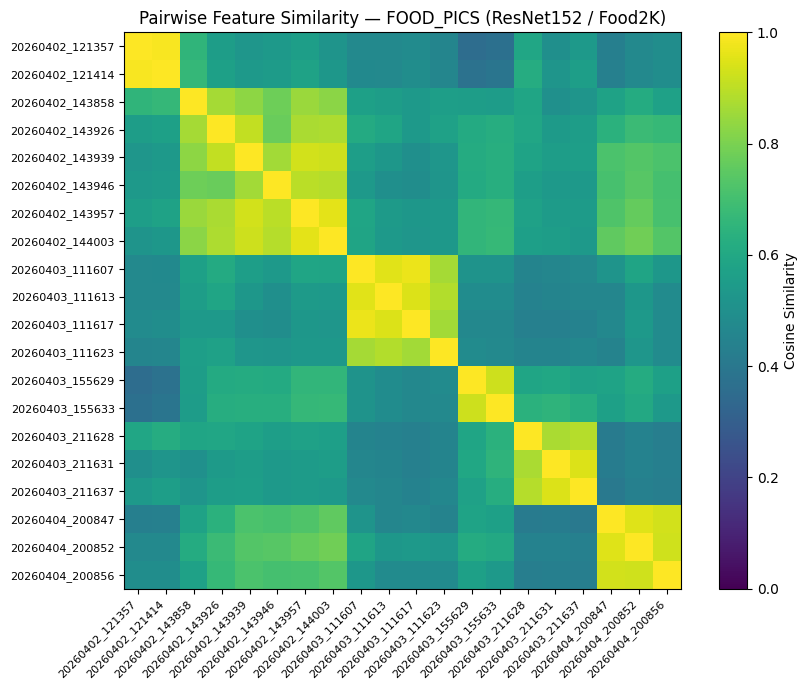

Saved similarity_matrix.png to FEATURED_FOOD_PICS


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

pt_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith('.pt')])
stems    = [os.path.splitext(f)[0] for f in pt_files]
matrix   = np.vstack([
    torch.load(os.path.join(OUTPUT_DIR, f))[0].numpy()  # [0] = features
    for f in pt_files
])

sim = cosine_similarity(matrix)

plt.figure(figsize=(9, 7))
plt.imshow(sim, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(stems)), stems, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(stems)), stems, fontsize=8)
plt.title('Pairwise Feature Similarity — FOOD_PICS (ResNet152 / Food2K)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_matrix.png'), dpi=150)
plt.show()
print('Saved similarity_matrix.png to FEATURED_FOOD_PICS')

# TESTING


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

FEATURE_DIR    = '/content/drive/MyDrive/FEATURED_FOOD_PICS'
CHECKPOINT_DIR = '/content/drive/MyDrive/MIE1517 Project/checkpoints_food_pics'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

pt_files = sorted([f for f in os.listdir(FEATURE_DIR) if f.endswith('.pt')])
print(f'Found {len(pt_files)} .pt feature files in FEATURED_FOOD_PICS')
for f in pt_files:
    print(' ', f)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 20 .pt feature files in FEATURED_FOOD_PICS
  20260402_121357.pt
  20260402_121414.pt
  20260402_143858.pt
  20260402_143926.pt
  20260402_143939.pt
  20260402_143946.pt
  20260402_143957.pt
  20260402_144003.pt
  20260403_111607.pt
  20260403_111613.pt
  20260403_111617.pt
  20260403_111623.pt
  20260403_155629.pt
  20260403_155633.pt
  20260403_211628.pt
  20260403_211631.pt
  20260403_211637.pt
  20260404_200847.pt
  20260404_200852.pt
  20260404_200856.pt


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Denormalisation constants — same order as feature extraction labels
# [calories_kcal, carbohydrate_g, fat_g, protein_g]
NORMS        = torch.tensor([3500.0, 650.0, 250.0, 250.0])
NUTRIENT_KEYS = ['calories_kcal', 'carbohydrate_g', 'fat_g', 'protein_g']
NUTRIENT_UNITS = ['kcal', 'g', 'g', 'g']

class NutritionPredictor(nn.Module):
    def __init__(self, input_dim=2048, output_dim=4):
        super(NutritionPredictor, self).__init__()
        self.name = 'nutrition_predictor_dropout_256'
        self.regressor = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.regressor(x)

model = NutritionPredictor().to(device)
print(model)


Using device: cuda
NutritionPredictor(
  (regressor): Sequential(
    (0): Linear(in_features=2048, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [ ]:
class FeaturedFoodDataset(Dataset):

    def __init__(self, feature_dir, file_list):
        self.feature_dir = feature_dir
        self.files       = file_list

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.feature_dir, self.files[idx])
        features, labels = torch.load(path)
        return features.squeeze(0).float(), labels.squeeze(0).float()

all_files = sorted([f for f in os.listdir(FEATURE_DIR) if f.endswith('.pt')])
n         = len(all_files)
n_train   = max(1, int(n * 0.70))
n_val     = max(1, int(n * 0.15))

train_files = all_files[:n_train]
val_files   = all_files[n_train:n_train + n_val]
test_files  = all_files[n_train + n_val:]

if not val_files:
    val_files  = all_files[-2:-1]
if not test_files:
    test_files = all_files[-1:]

print(f'Split  →  train: {len(train_files)}  |  val: {len(val_files)}  |  test: {len(test_files)}')

BATCH_SIZE = 4   # small — dataset is tiny

train_dataset = FeaturedFoodDataset(FEATURE_DIR, train_files)
val_dataset   = FeaturedFoodDataset(FEATURE_DIR, val_files)
test_dataset  = FeaturedFoodDataset(FEATURE_DIR, test_files)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}')


Split  →  train: 14  |  val: 3  |  test: 3
Train batches: 4  |  Val batches: 1  |  Test batches: 1


In [ ]:
def get_model_name(name, batch_size, learning_rate, epoch):
    return f'model_{name}_bs{batch_size}_lr{learning_rate}_epoch{epoch}'

def plot_training_curve(train_mae, val_mae, model_name=''):
    """Plot per-nutrient MAE curves from numpy arrays of shape (epochs, 4)."""
    epochs = np.arange(1, len(train_mae) + 1)
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f'Training Curves — {model_name}', fontsize=13)
    for ax, key, unit, tr, va in zip(axes, NUTRIENT_KEYS, NUTRIENT_UNITS,
                                     train_mae.T, val_mae.T):
        ax.plot(epochs, tr, label='Train', marker='o')
        ax.plot(epochs, va, label='Val',   marker='s')
        ax.set_title(key)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(f'MAE ({unit})')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
def evaluate(net, loader, criterion):
    net.eval()
    norms        = NORMS.to(device)
    total_mae    = torch.zeros(4).to(device)
    total_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels   = labels.to(device).float()
            outputs  = net(features)

            preds_raw  = outputs * norms
            labels_raw = labels  * norms

            total_mae     += torch.abs(preds_raw - labels_raw).sum(dim=0)
            total_samples += labels.shape[0]

            all_preds.extend(preds_raw.cpu().numpy())
            all_labels.extend(labels_raw.cpu().numpy())

    avg_mae = (total_mae / total_samples).cpu().numpy() if total_samples > 0 else np.zeros(4)
    return avg_mae, np.array(all_labels), np.array(all_preds)


In [ ]:
def train(net, train_loader, val_loader, checkpoint_dir,
          batch_size=4, learning_rate=0.001, num_epochs=20):
    """
    Trains NutritionPredictor on FEATURED_FOOD_PICS features.
    Supports checkpoint resuming.  Saves .pt + _train_err.csv / _val_err.csv.
    """
    net = net.to(device)
    norms = NORMS.to(device)

    start_epoch = 0
    existing = [f for f in os.listdir(checkpoint_dir)
                if f.startswith(f'model_{net.name}_bs{batch_size}_lr{learning_rate}')
                and not f.endswith('.csv')]
    if existing:
        try:
            epochs_found = []
            for f in existing:
                num = ''.join(filter(str.isdigit, f.split('epoch')[-1]))
                if num:
                    epochs_found.append(int(num))
            if epochs_found:
                last_epoch = max(epochs_found)
                load_path  = os.path.join(checkpoint_dir,
                                          get_model_name(net.name, batch_size, learning_rate, last_epoch))
                print(f'Resuming from epoch {last_epoch + 1}  ({load_path})')
                net.load_state_dict(torch.load(load_path, map_location=device))
                start_epoch = last_epoch + 1
        except Exception as e:
            print(f'Resume failed ({e}), starting from 0.')
    else:
        print('No checkpoint found — starting from epoch 0.')

    criterion = nn.MSELoss()
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    end_epoch = start_epoch + num_epochs

    train_mae = np.zeros((end_epoch, 4))
    val_mae   = np.zeros((end_epoch, 4))

    if start_epoch > 0:
        old_path = os.path.join(checkpoint_dir,
                                get_model_name(net.name, batch_size, learning_rate, last_epoch))
        try:
            train_mae[:start_epoch] = np.loadtxt(f'{old_path}_train_err.csv').reshape(-1, 4)
            val_mae[:start_epoch]   = np.loadtxt(f'{old_path}_val_err.csv').reshape(-1, 4)
            print(f'Loaded {start_epoch} epochs of CSV history.')
        except Exception as e:
            print(f'Could not load CSV history: {e}')
    for epoch in range(start_epoch, end_epoch):
        net.train()
        ep_mae    = torch.zeros(4).to(device)
        ep_samples = 0

        for features, labels in train_loader:
            features = features.to(device)
            labels   = labels.to(device).float()

            optimizer.zero_grad()
            outputs = net(features)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds_raw  = outputs.detach() * norms
            labels_raw = labels * norms
            ep_mae     += torch.abs(preds_raw - labels_raw).sum(dim=0)
            ep_samples += labels.shape[0]

        train_mae[epoch] = (ep_mae / ep_samples).cpu().numpy()
        val_mae[epoch], _, _ = evaluate(net, val_loader, criterion)

        print(f'Epoch {epoch + 1}/{end_epoch}:')
        for key, unit, tr, va in zip(NUTRIENT_KEYS, NUTRIENT_UNITS,
                                     train_mae[epoch], val_mae[epoch]):
            print(f'  {key:<22}  Train MAE: {tr:7.2f} {unit}  |  Val MAE: {va:7.2f} {unit}')

        # Save checkpoint + CSVs
        model_path = os.path.join(checkpoint_dir,
                                  get_model_name(net.name, batch_size, learning_rate, epoch))
        torch.save(net.state_dict(), model_path)
        np.savetxt(f'{model_path}_train_err.csv', train_mae[:epoch + 1])
        np.savetxt(f'{model_path}_val_err.csv',   val_mae[:epoch + 1])

    return train_mae[:end_epoch], val_mae[:end_epoch]


In [ ]:
model = NutritionPredictor().to(device)

train_mae, val_mae = train(
    model,
    train_loader   = train_loader,
    val_loader     = val_loader,
    checkpoint_dir = CHECKPOINT_DIR,
    batch_size     = BATCH_SIZE,
    learning_rate  = 0.001,
    num_epochs     = 30,      # increase if you want more training
)

No checkpoint found — starting from epoch 0.
Epoch 1/30:
  calories_kcal           Train MAE:  439.42 kcal  |  Val MAE:  300.27 kcal
  carbohydrate_g          Train MAE:  129.46 g  |  Val MAE:   64.64 g
  fat_g                   Train MAE:   46.26 g  |  Val MAE:    7.09 g
  protein_g               Train MAE:   45.65 g  |  Val MAE:   33.36 g
Epoch 2/30:
  calories_kcal           Train MAE:  527.64 kcal  |  Val MAE:  636.20 kcal
  carbohydrate_g          Train MAE:  157.92 g  |  Val MAE:   71.37 g
  fat_g                   Train MAE:   27.94 g  |  Val MAE:    6.13 g
  protein_g               Train MAE:   32.79 g  |  Val MAE:   13.09 g
Epoch 3/30:
  calories_kcal           Train MAE:  387.21 kcal  |  Val MAE:  617.48 kcal
  carbohydrate_g          Train MAE:  169.07 g  |  Val MAE:   72.91 g
  fat_g                   Train MAE:   28.40 g  |  Val MAE:   10.43 g
  protein_g               Train MAE:   42.39 g  |  Val MAE:    6.16 g
Epoch 4/30:
  calories_kcal           Train MAE:  400.90 kcal

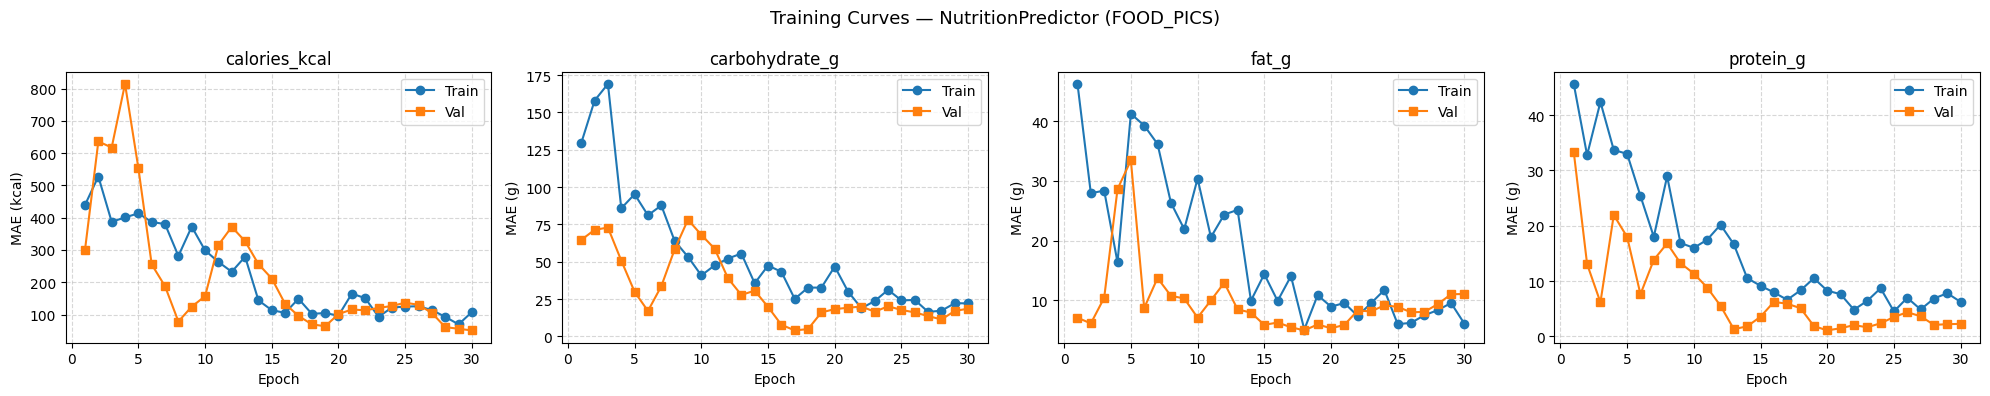

In [ ]:
plot_training_curve(train_mae, val_mae, model_name='NutritionPredictor (FOOD_PICS)')


In [ ]:
criterion = nn.MSELoss()
test_mae, test_labels, test_preds = evaluate(model, test_loader, criterion)

print('\n── Test MAE (real units) ──')
for key, unit, mae in zip(NUTRIENT_KEYS, NUTRIENT_UNITS, test_mae):
    print(f'  {key:<22}  {mae:.2f} {unit}')



── Test MAE (real units) ──
  calories_kcal           74.03 kcal
  carbohydrate_g          18.12 g
  fat_g                   4.94 g
  protein_g               0.37 g


In [ ]:
import os
import torch
import numpy as np
import pandas as pd

# ── Step 1: Load checkpoint directly by path ───────────────────────────────────
ckpt_path = '/content/model_nutrition_predictor_dropout_256_bs128_lr0.001_epoch62'

model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f'Loaded checkpoint: {os.path.basename(ckpt_path)}')

# ── Step 2: Run inference on all FEATURED_FOOD_PICS ────────────────────────────
norms_np = NORMS.numpy()   # [3500, 650, 250, 250]

rows = []
with torch.no_grad():
    for fname in sorted([f for f in os.listdir(FEATURE_DIR) if f.endswith('.pt')]):
        features, _ = torch.load(os.path.join(FEATURE_DIR, fname))
        features     = features.to(device).float()
        pred_norm    = model(features).cpu().numpy().squeeze()  # (4,) normalised
        pred_raw     = pred_norm * norms_np                     # (4,) real units

        rows.append({
            'image'          : fname.replace('.pt', ''),
            'calories (kcal)': round(float(pred_raw[0]), 1),
            'protein (g)'    : round(float(pred_raw[1]), 1),
            'fat (g)'        : round(float(pred_raw[2]), 1),
            'carbs (g)'      : round(float(pred_raw[3]), 1),
        })

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(df.to_string(index=False))

csv_path = '/content/drive/MyDrive/FEATURED_FOOD_PICS/predictions.csv'
df.to_csv(csv_path, index=False)
print(f'\nSaved to {csv_path}')

Loaded checkpoint: model_nutrition_predictor_dropout_256_bs128_lr0.001_epoch62
          image  calories (kcal)  protein (g)  fat (g)  carbs (g)
20260402_121357            356.9         54.3     16.6       10.8
20260402_121414            404.2         56.1     17.7       14.4
20260402_143858            333.9         52.7     16.9        8.2
20260402_143926            560.0         67.5     21.7       24.3
20260402_143939            525.6         60.4     20.2       23.3
20260402_143946            361.2         47.3     15.6       13.1
20260402_143957            409.7         48.5     16.1       17.4
20260402_144003            500.6         57.6     19.6       21.9
20260403_111607            475.5         42.4     13.0       28.4
20260403_111613            355.3         27.8      7.6       23.2
20260403_111617            370.3         28.7      9.0       23.6
20260403_111623            352.3         39.5     15.5       14.3
20260403_155629            487.8         60.3     19.2       20

# ALL IN ONE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Found 2 images in /content/drive/MyDrive/TEST_IMGS
ResNet152 feature extractor ready

Extracting features...
Features saved in 0.3s  →  /content/drive/MyDrive/FEATURED_TEST_IMGS
Loaded NutritionPredictor: model_nutrition_predictor_dropout_256_bs128_lr0.001_epoch62


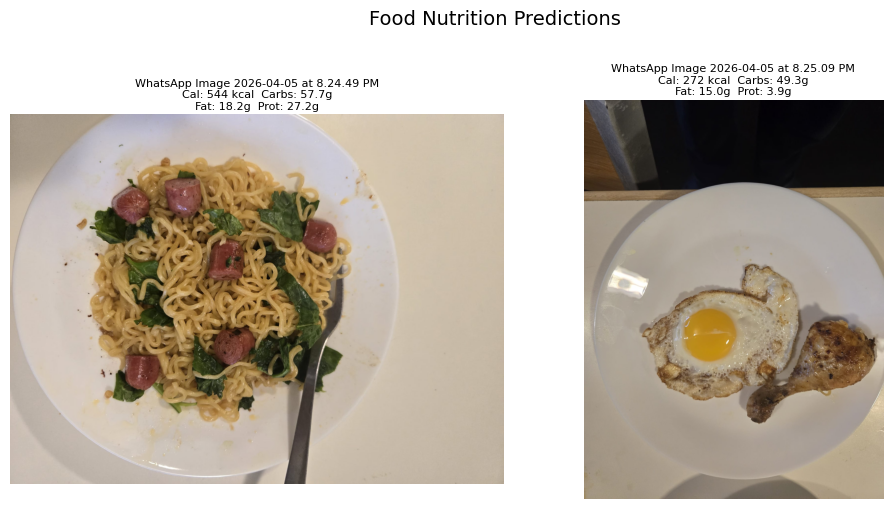


── Nutrition Predictions ──
                                  image  calories (kcal)  protein (g)  fat (g)  carbs (g)
WhatsApp Image 2026-04-05 at 8.24.49 PM            544.4         57.7     18.2       27.2
WhatsApp Image 2026-04-05 at 8.25.09 PM            272.5         49.3     15.0        3.9

Saved table  →  /content/drive/MyDrive/FEATURED_TEST_IMGS/predictions.csv
Saved grid   →  /content/drive/MyDrive/FEATURED_TEST_IMGS/predictions_grid.png


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

IMAGE_DIR   = '/content/drive/MyDrive/TEST_IMGS'
FEATURE_DIR = '/content/drive/MyDrive/FEATURED_TEST_IMGS'   # ← separate folder
RESNET_WEIGHTS = '/content/food2k_resnet152_0.0001.pth'
NUTRITION_CKPT = '/content/model_nutrition_predictor_dropout_256_bs128_lr0.001_epoch62'

NORMS         = torch.tensor([3500.0, 650.0, 250.0, 250.0])
NUTRIENT_KEYS = ['Calories (kcal)','Protein (g)', 'Fat (g)', 'Carbs (g)']
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
os.makedirs(FEATURE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

image_paths = sorted([
    os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR)
    if os.path.splitext(f)[1].lower() in SUPPORTED_EXTS
])
print(f'Found {len(image_paths)} images in {IMAGE_DIR}')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths, self.transform = paths, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        path = self.paths[idx]
        img  = Image.open(path).convert('RGB')
        stem = os.path.splitext(os.path.basename(path))[0]
        return self.transform(img), stem

resnet = models.resnet152(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2000)
state_dict = torch.load(RESNET_WEIGHTS, map_location=device)
resnet.load_state_dict({k.replace('module.', ''): v for k, v in state_dict.items()})
feature_extractor = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()
print('ResNet152 feature extractor ready')

loader = DataLoader(ImageDataset(image_paths, preprocess),
                    batch_size=8, shuffle=False, num_workers=2)
print('\nExtracting features...')
t0 = time.time()
with torch.no_grad():
    for imgs, stems in loader:
        feats = feature_extractor(imgs.to(device)).view(imgs.size(0), -1)
        for i, stem in enumerate(stems):
            feat_i = feats[i].cpu().unsqueeze(0)              # (1, 2048)
            label_i = torch.zeros(1, 4, dtype=torch.float32)  # (1, 4) placeholder
            torch.save((feat_i, label_i), os.path.join(FEATURE_DIR, f'{stem}.pt'))
print(f'Features saved in {time.time()-t0:.1f}s  →  {FEATURE_DIR}')

class NutritionPredictor(nn.Module):
    def __init__(self, input_dim=2048, output_dim=4):
        super().__init__()
        self.name = 'nutrition_predictor_dropout_256'
        self.regressor = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x):
        return self.regressor(x)

predictor = NutritionPredictor().to(device)
predictor.load_state_dict(torch.load(NUTRITION_CKPT, map_location=device))
predictor.eval()
print(f'Loaded NutritionPredictor: {os.path.basename(NUTRITION_CKPT)}')

norms_np  = NORMS.numpy()
pt_files  = sorted([f for f in os.listdir(FEATURE_DIR) if f.endswith('.pt')])
n         = len(pt_files)
ncols     = min(4, n)
nrows     = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes      = np.array(axes).flatten()

rows = []
with torch.no_grad():
    for idx, fname in enumerate(pt_files):
        stem     = fname.replace('.pt', '')
        features, _ = torch.load(os.path.join(FEATURE_DIR, fname))
        pred_raw = (predictor(features.to(device).float())
                    .cpu().numpy().squeeze() * norms_np)

        img_path = next(
            (p for p in image_paths if os.path.splitext(os.path.basename(p))[0] == stem),
            None
        )

        ax = axes[idx]
        if img_path:
            ax.imshow(Image.open(img_path).convert('RGB'))
        else:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')

        title = (f'{stem}\n'
                 f'Cal: {pred_raw[0]:.0f} kcal  Carbs: {pred_raw[1]:.1f}g\n'
                 f'Fat: {pred_raw[2]:.1f}g  Prot: {pred_raw[3]:.1f}g')
        ax.set_title(title, fontsize=8, pad=4)
        ax.axis('off')

        rows.append({
            'image'          : stem,
            'calories (kcal)': round(float(pred_raw[0]), 1),
            'protein (g)'      : round(float(pred_raw[1]), 1),
            'fat (g)'        : round(float(pred_raw[2]), 1),
            'carbs (g)'   : round(float(pred_raw[3]), 1),
        })

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Food Nutrition Predictions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_DIR, 'predictions_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('\n── Nutrition Predictions ──')
print(df.to_string(index=False))

csv_path = os.path.join(FEATURE_DIR, 'predictions.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved table  →  {csv_path}')
print(f'Saved grid   →  {FEATURE_DIR}/predictions_grid.png')

# TEST ON AUGMENTED IMAGE

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Found 20 images in /content/drive/MyDrive/Augmented_FOOD_PICS
ResNet152 feature extractor ready

Extracting features...
Features saved in 8.0s  →  /content/drive/MyDrive/FEATURED_Augmented_FOOD_PICS
Loaded NutritionPredictor: model_nutrition_predictor_dropout_256_bs128_lr0.001_epoch62


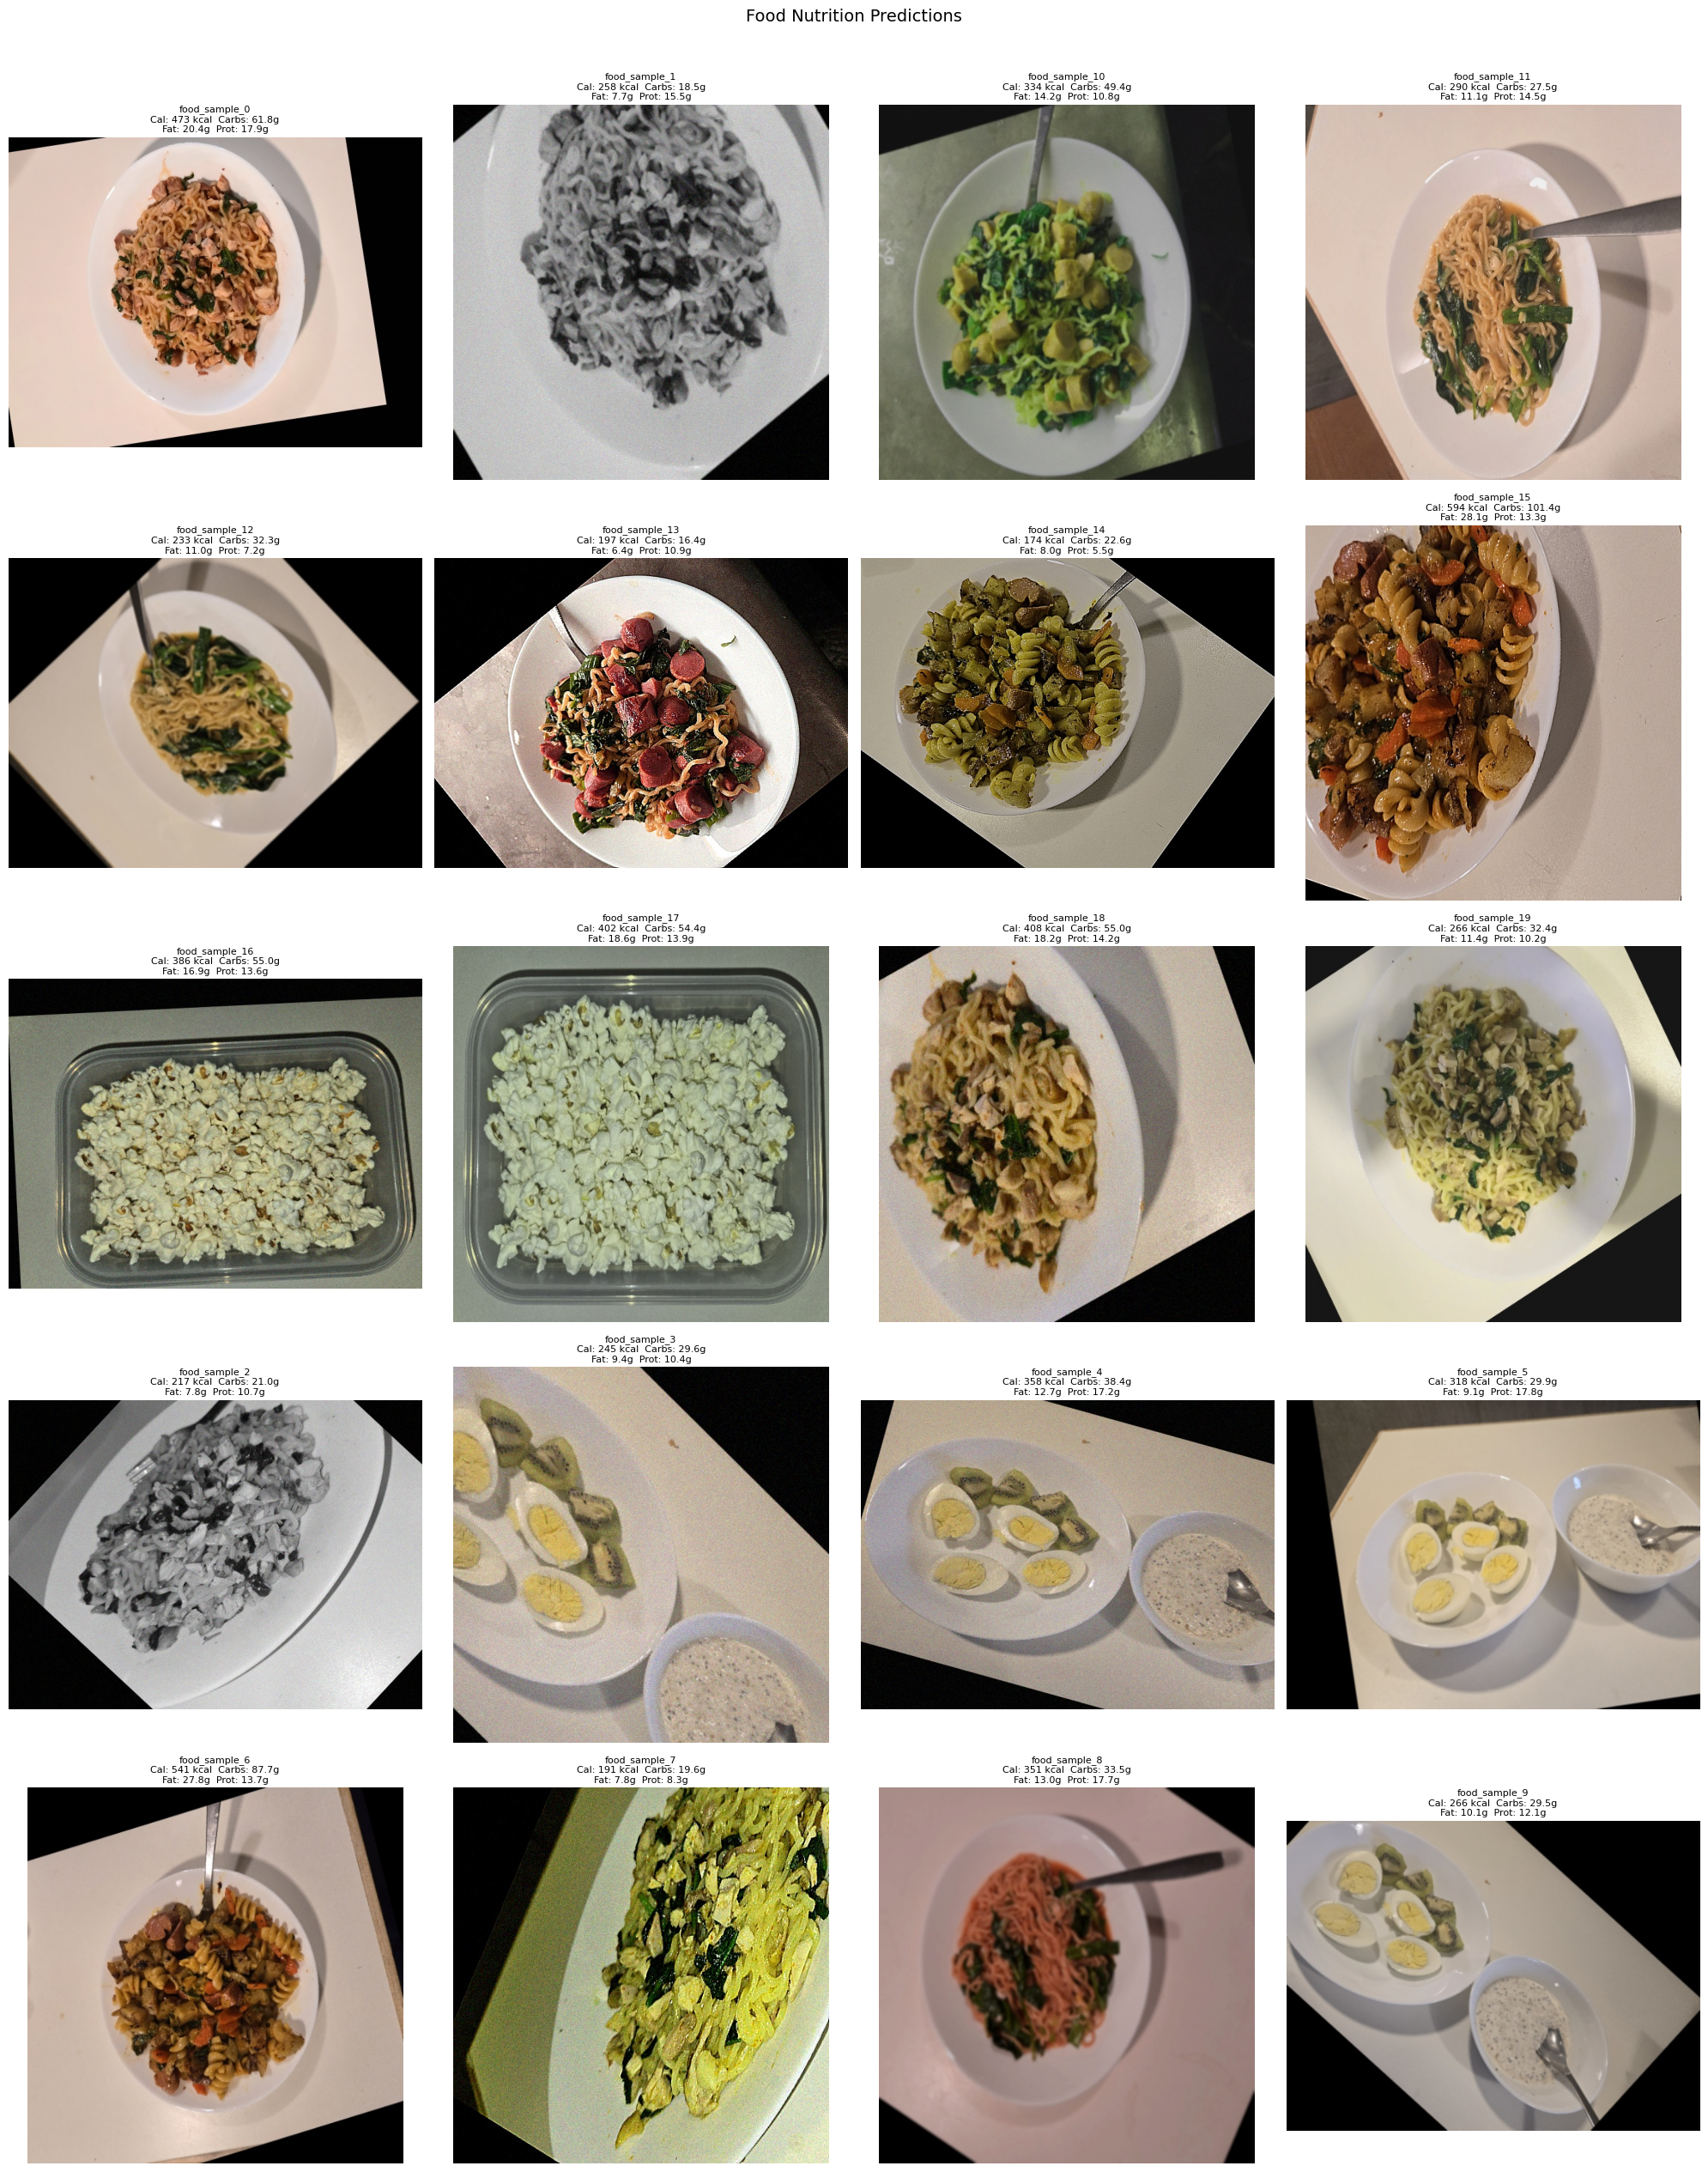


── Nutrition Predictions ──
         image  calories (kcal)  protein (g)  fat (g)  carbs (g)
 food_sample_0            473.2         61.8     20.4       17.9
 food_sample_1            258.1         18.5      7.7       15.5
food_sample_10            333.8         49.4     14.2       10.8
food_sample_11            290.4         27.5     11.1       14.5
food_sample_12            233.4         32.3     11.0        7.2
food_sample_13            196.7         16.4      6.4       10.9
food_sample_14            173.9         22.6      8.0        5.5
food_sample_15            594.2        101.4     28.1       13.3
food_sample_16            386.2         55.0     16.9       13.6
food_sample_17            401.9         54.4     18.6       13.9
food_sample_18            407.7         55.0     18.2       14.2
food_sample_19            266.3         32.4     11.4       10.2
 food_sample_2            216.6         21.0      7.8       10.7
 food_sample_3            245.1         29.6      9.4       1

In [60]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

IMAGE_DIR   = '/content/drive/MyDrive/Augmented_FOOD_PICS'
FEATURE_DIR = '/content/drive/MyDrive/FEATURED_Augmented_FOOD_PICS'   # ← separate folder
RESNET_WEIGHTS = '/content/food2k_resnet152_0.0001.pth'
NUTRITION_CKPT = '/content/model_nutrition_predictor_dropout_256_bs128_lr0.001_epoch62'

NORMS         = torch.tensor([3500.0, 650.0, 250.0, 250.0])
NUTRIENT_KEYS = ['Calories (kcal)','Protein (g)', 'Fat (g)','Carbs (g)']
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
os.makedirs(FEATURE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

image_paths = sorted([
    os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR)
    if os.path.splitext(f)[1].lower() in SUPPORTED_EXTS
])
print(f'Found {len(image_paths)} images in {IMAGE_DIR}')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths, self.transform = paths, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        path = self.paths[idx]
        img  = Image.open(path).convert('RGB')
        stem = os.path.splitext(os.path.basename(path))[0]
        return self.transform(img), stem

resnet = models.resnet152(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2000)
state_dict = torch.load(RESNET_WEIGHTS, map_location=device)
resnet.load_state_dict({k.replace('module.', ''): v for k, v in state_dict.items()})
feature_extractor = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()
print('ResNet152 feature extractor ready')

loader = DataLoader(ImageDataset(image_paths, preprocess),
                    batch_size=8, shuffle=False, num_workers=2)
print('\nExtracting features...')
t0 = time.time()
with torch.no_grad():
    for imgs, stems in loader:
        feats = feature_extractor(imgs.to(device)).view(imgs.size(0), -1)
        for i, stem in enumerate(stems):
            feat_i = feats[i].cpu().unsqueeze(0)              # (1, 2048)
            label_i = torch.zeros(1, 4, dtype=torch.float32)  # (1, 4) placeholder
            torch.save((feat_i, label_i), os.path.join(FEATURE_DIR, f'{stem}.pt'))
print(f'Features saved in {time.time()-t0:.1f}s  →  {FEATURE_DIR}')

class NutritionPredictor(nn.Module):
    def __init__(self, input_dim=2048, output_dim=4):
        super().__init__()
        self.name = 'nutrition_predictor_dropout_256'
        self.regressor = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, output_dim)
        )
    def forward(self, x):
        return self.regressor(x)

predictor = NutritionPredictor().to(device)
predictor.load_state_dict(torch.load(NUTRITION_CKPT, map_location=device))
predictor.eval()
print(f'Loaded NutritionPredictor: {os.path.basename(NUTRITION_CKPT)}')

norms_np  = NORMS.numpy()
pt_files  = sorted([f for f in os.listdir(FEATURE_DIR) if f.endswith('.pt')])
n         = len(pt_files)
ncols     = min(4, n)
nrows     = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes      = np.array(axes).flatten()

rows = []
with torch.no_grad():
    for idx, fname in enumerate(pt_files):
        stem     = fname.replace('.pt', '')
        features, _ = torch.load(os.path.join(FEATURE_DIR, fname))
        pred_raw = (predictor(features.to(device).float())
                    .cpu().numpy().squeeze() * norms_np)

        img_path = next(
            (p for p in image_paths if os.path.splitext(os.path.basename(p))[0] == stem),
            None
        )

        ax = axes[idx]
        if img_path:
            ax.imshow(Image.open(img_path).convert('RGB'))
        else:
            ax.text(0.5, 0.5, 'No image', ha='center', va='center')

        title = (f'{stem}\n'
                 f'Cal: {pred_raw[0]:.0f} kcal  Carbs: {pred_raw[1]:.1f}g\n'
                 f'Fat: {pred_raw[2]:.1f}g  Prot: {pred_raw[3]:.1f}g')
        ax.set_title(title, fontsize=8, pad=4)
        ax.axis('off')

        rows.append({
            'image'          : stem,
            'calories (kcal)': round(float(pred_raw[0]), 1),
            'protein (g)'      : round(float(pred_raw[1]), 1),
            'fat (g)'        : round(float(pred_raw[2]), 1),
            'carbs (g)'   : round(float(pred_raw[3]), 1),
        })

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Food Nutrition Predictions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FEATURE_DIR, 'predictions_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('\n── Nutrition Predictions ──')
print(df.to_string(index=False))

csv_path = os.path.join(FEATURE_DIR, 'predictions.csv')
df.to_csv(csv_path, index=False)
print(f'\nSaved table  →  {csv_path}')
print(f'Saved grid   →  {FEATURE_DIR}/predictions_grid.png')